### PHASE 1 : PREPROCESSING
* BCI Competition IV Dataset 2a
* Channels: All 22 channels
* All subjects: A01, A02, A03, A04, A05, A06, A07, A08, A09


In [1]:
import warnings
import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import scipy.io

warnings.filterwarnings(
    "ignore",
    message="Could not determine channel type of the following channels, they will be set as EEG:*"
 )

Demo Subject 1 Train EEG shape: (143, 22, 1001)
Demo Subject 1 Train labels shape: (143,)
Demo Subject 1 Test EEG shape: (144, 22, 1001)
Demo Subject 1 Test labels shape: (144,)


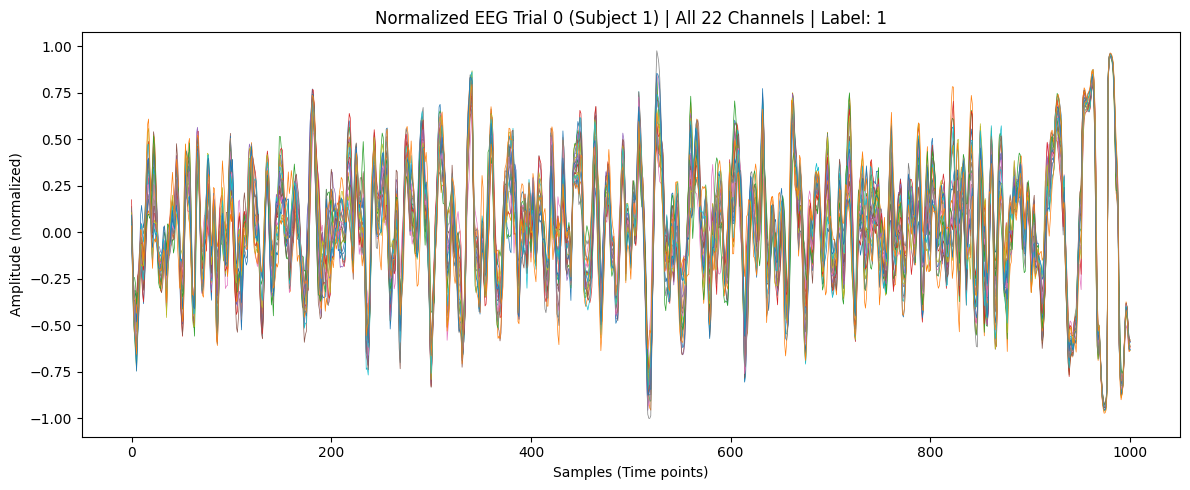

In [2]:
# Preprocessing both Train (T) and Test (E) files
import mne
import scipy.io
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_subject(subject, run_type="T"):
    # A01T.gdf / A01E.gdf, etc.
    file_path = f"BCICIV_2a_gdf/A{subject:02d}{run_type}.gdf"

    # Load EEG recording
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose="ERROR")

    # If it's test/evaluation set, replace '783' annotations with actual labels from mat file
    if run_type == "E":
        mat_path = file_path.replace(".gdf", ".mat")
        mat_data = scipy.io.loadmat(mat_path)
        classlabel = mat_data['classlabel'].flatten() # array of shape (288,)
        
        # Map mat class labels (1, 2, 3, 4) to GDF annotation strings
        label_map = {1: '769', 2: '770', 3: '771', 4: '772'}
        test_annotations = [label_map[lbl] for lbl in classlabel]
        
        # Replace '783' annotations in raw
        descriptions = raw.annotations.description.copy()
        idx = 0
        for i, desc in enumerate(descriptions):
            if desc == '783':
                descriptions[i] = test_annotations[idx]
                idx += 1
        raw.annotations.description = descriptions

    # Explicitly mark known EOG channels when present
    eog_channels = ["EOG-left", "EOG-central", "EOG-right"]
    present_eog = {ch: "eog" for ch in eog_channels if ch in raw.ch_names}
    if present_eog:
        raw.set_channel_types(present_eog)

    # Keeping all EEG channels (excluding EOG channels)
    eeg_channels = [ch for ch in raw.ch_names if ch.startswith("EEG")]
    raw.pick(eeg_channels)

    # Motor imagery frequency range (alpha, beta) bandpass filtering
    raw.filter(8, 30, verbose="ERROR")

    # Extract event markers
    events, event_dict = mne.events_from_annotations(raw, verbose="ERROR")

    # Keep only left hand ("769") and right hand ("770") events
    available_events = {
        k: v for k, v in event_dict.items()
        if k in ["769", "770"]
    }

    # Create trials from 2s to 6s after cue
    epochs = mne.Epochs(
        raw,
        events,
        event_id=available_events,
        tmin=2,
        tmax=6,
        baseline=None,
        preload=True,
        verbose="ERROR"
    )

    # EEG data
    X = epochs.get_data()

    # Labels
    y_label = epochs.events[:, 2]

    # Map MNE internal IDs for '769' (left) and '770' (right) to 0 and 1 remapping
    subject_label_map = {}
    if "769" in epochs.event_id:
        subject_label_map[epochs.event_id["769"]] = 0
    if "770" in epochs.event_id:
        subject_label_map[epochs.event_id["770"]] = 1
    y_label = np.vectorize(subject_label_map.get)(y_label).astype(np.int64)

    # Normalize EEG values to [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_flat = X.reshape(-1, X.shape[-1])
    X_norm = scaler.fit_transform(X_flat).reshape(X.shape)
    
    return X_norm, y_label

# Demonstration: preprocess and plot for Subject 1
X_train_norm_demo, y_train_demo = load_and_preprocess_subject(1, "T")
X_test_norm_demo, y_test_demo = load_and_preprocess_subject(1, "E")

# Keep 'y' pointing to 'y_train_demo' so that standard code cells don't break
y = y_train_demo

print("Demo Subject 1 Train EEG shape:", X_train_norm_demo.shape)
print("Demo Subject 1 Train labels shape:", y_train_demo.shape)
print("Demo Subject 1 Test EEG shape:", X_test_norm_demo.shape)
print("Demo Subject 1 Test labels shape:", y_test_demo.shape)

# visualization: first trial, all 22 channels from training set
trial_idx = 0
plt.figure(figsize=(12, 5))
for ch_idx in range(X_train_norm_demo.shape[1]):
    plt.plot(X_train_norm_demo[trial_idx, ch_idx, :], linewidth=0.5)

plt.title(f"Normalized EEG Trial {trial_idx} (Subject 1) | All 22 Channels | Label: {y_train_demo[trial_idx]}")
plt.xlabel("Samples (Time points)")
plt.ylabel("Amplitude (normalized)")
plt.tight_layout()
plt.show()


### PHASE 2: DATA LOADING & Z-SCORE NORMALIZATION

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    SeparableConv2D,
    AveragePooling2D,
    BatchNormalization,
    Activation,
    Dense,
    Dropout,
    Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.constraints import max_norm

In [4]:
print(np.unique(y, return_counts=True))

(array([0, 1]), array([71, 72]))


In [5]:
# STEP 1: DEFINE NORMALIZATION FOR SUBJECT-WISE EEG DATA
def z_score_normalize_subject(X_train_data, X_test_data):
    # Per-trial, across-channels z-score normalization to preserve relative channel variances
    X_train_data = X_train_data.astype(np.float32)
    mean_tr = X_train_data.mean(axis=(1, 2), keepdims=True)
    std_tr = X_train_data.std(axis=(1, 2), keepdims=True)
    X_train_norm = (X_train_data - mean_tr) / (std_tr + 1e-8)
    X_train_norm = np.nan_to_num(X_train_norm)
    
    X_test_data = X_test_data.astype(np.float32)
    mean_te = X_test_data.mean(axis=(1, 2), keepdims=True)
    std_te = X_test_data.std(axis=(1, 2), keepdims=True)
    X_test_norm = (X_test_data - mean_te) / (std_te + 1e-8)
    X_test_norm = np.nan_to_num(X_test_norm)
    
    return X_train_norm, X_test_norm

print("Subject-wise normalization function defined successfully.")


Subject-wise normalization function defined successfully.


### PHASE 3: CONDITIONAL WGAN-GP DEVELOPMENT

Implementing Conditional Wasserstein GAN with Gradient Penalty (WGAN-GP) to generate synthetic EEG data for the two motor imagery classes: Left Hand (0) and Right Hand (1).
- Both Generator and Critic use 1D convolutional layers.
- Generator upsamples using bilinear interpolation to prevent high-frequency checkerboard artifacts.
- To run efficiently on CPU, i am using a compact convolutional design with kernel size 7.
- Training runs with gradient penalty constraint.

critic loss :
- Very large negative  → Critic is much stronger than Generator
- Closer to zero       → Real and fake distributions are becoming similar

In [6]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Conv1D, Embedding, Flatten, Concatenate, Lambda, LeakyReLU
import numpy as np

# WGAN-GP Hyperparameters
latent_dim = 100    # The size of the random noise vector (generator seed)
gp_weight = 10.0     # Gradient penalty weight
n_critic = 5        # Number of critic updates per generator update
batch_size = 64     # Batch size for training

# STEP 2: DEFINE GENERATOR & CRITIC
def resize_1d(x, new_length):
    # Interpolation-based upsampling
    x_4d = tf.expand_dims(x, axis=2)
    x_resized = tf.image.resize(x_4d, [new_length, 1], method='bilinear')
    return tf.squeeze(x_resized, axis=2)

def make_generator():
    noise_in = Input(shape=(latent_dim,))
    label_in = Input(shape=(1,), dtype='int32')
    
    label_emb = Embedding(input_dim=2, output_dim=50)(label_in)
    label_emb = Flatten()(label_emb)
    
    x = Concatenate()([noise_in, label_emb])
    x = Dense(125 * 64, activation='relu')(x)
    x = Reshape((125, 64))(x)
    x = Conv1D(64, kernel_size=7, padding='same', activation='relu')(x)
    
    x = Lambda(lambda t: resize_1d(t, 250))(x)
    x = Conv1D(64, kernel_size=7, padding='same', activation='relu')(x)
    
    x = Lambda(lambda t: resize_1d(t, 500))(x)
    x = Conv1D(32, kernel_size=7, padding='same', activation='relu')(x)
    
    x = Lambda(lambda t: resize_1d(t, 1001))(x)
    x_out = Conv1D(22, kernel_size=7, padding='same')(x) # Output 22 channels (all channels)
    
    return Model([noise_in, label_in], x_out, name="Generator")

def make_critic():
    eeg_in = Input(shape=(1001, 22)) # Input shape with 22 channels
    label_in = Input(shape=(1,), dtype='int32')
    
    label_emb = Embedding(input_dim=2, output_dim=50)(label_in)
    label_emb = Dense(1001)(label_emb)
    label_emb = Reshape((1001, 1))(label_emb)
    
    x = Concatenate(axis=-1)([eeg_in, label_emb])
    
    x = Conv1D(32, kernel_size=7, strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Conv1D(64, kernel_size=7, strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    x = Conv1D(128, kernel_size=7, strides=2, padding='same')(x)
    x = LeakyReLU(0.2)(x)
    
    x = Flatten()(x)
    x_out = Dense(1)(x)
    
    return Model([eeg_in, label_in], x_out, name="Critic")


In [7]:
# STEP 3: CUSTOM WGAN-GP TRAINING LOOP WRAPPED IN A HELPER FUNCTION
def train_wgan_gp_for_subject(X_real_data, y_train_data, epochs=15, verbose=False):
    X_real_data = X_real_data.astype(np.float32) # Ensure data type is float32 to avoid TF type mismatch
    # Transpose z-score normalized X_real_data from shape (samples, channels, time) to (samples, time, channels) for 1D CNN
    X_real_gan = np.transpose(X_real_data, (0, 2, 1)) # shape: (samples, 1001, 22)
    
    generator = make_generator()
    critic = make_critic()

    critic_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)
    gen_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5, beta_2=0.9)

    @tf.function
    def train_step(real_eeg, labels):
        for _ in range(n_critic):
            noise = tf.random.normal([batch_size, latent_dim])
            with tf.GradientTape() as critic_tape:
                fake_eeg = generator([noise, labels], training=True)
                d_real = critic([real_eeg, labels], training=True)
                d_fake = critic([fake_eeg, labels], training=True)
                
                epsilon = tf.random.uniform([batch_size, 1, 1], 0.0, 1.0)
                interpolated = epsilon * real_eeg + (1 - epsilon) * fake_eeg
                with tf.GradientTape() as gp_tape:
                    gp_tape.watch(interpolated)
                    d_hat = critic([interpolated, labels], training=True)
                
                gradients = gp_tape.gradient(d_hat, interpolated)
                norms = tf.sqrt(tf.reduce_sum(tf.square(gradients), axis=[1, 2]) + 1e-12)
                gp = tf.reduce_mean((norms - 1.0) ** 2)
                critic_loss = tf.reduce_mean(d_fake) - tf.reduce_mean(d_real) + gp_weight * gp

            gradients_critic = critic_tape.gradient(critic_loss, critic.trainable_variables)
            critic_optimizer.apply_gradients(zip(gradients_critic, critic.trainable_variables))
            
        noise = tf.random.normal([batch_size, latent_dim])
        with tf.GradientTape() as gen_tape:
            fake_eeg = generator([noise, labels], training=True)
            d_fake = critic([fake_eeg, labels], training=True)
            gen_loss = -tf.reduce_mean(d_fake)
            
        gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
        gen_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
        
        return critic_loss, gen_loss

    dataset = tf.data.Dataset.from_tensor_slices((X_real_gan, y_train_data)).shuffle(len(y_train_data)).batch(batch_size, drop_remainder=True)

    for epoch in range(epochs):
        c_losses = []
        g_losses = []
        for real_batch, labels_batch in dataset:
            labels_batch = tf.expand_dims(labels_batch, axis=-1)
            c_loss, g_loss = train_step(real_batch, labels_batch)
            c_losses.append(c_loss)
            g_losses.append(g_loss)
        
        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0):
            print(f"  Epoch {epoch+1:03d}/{epochs:03d} | Critic Loss: {np.mean(c_losses):.4f} | Generator Loss: {np.mean(g_losses):.4f}")
            
    return generator


### PHASE 4: SYNTHETIC DATA EVALUATION

Verifying the quality of generated EEG data in both the time and frequency domains, and calculate quantitative similarity metrics.
- SWD (closer to 0 is better)
- Pearson correlation (closer to 1 is better)

Training Demo Subject 1 Generator...

  Epoch 001/100 | Critic Loss: 3.8586 | Generator Loss: -0.0307
  Epoch 005/100 | Critic Loss: -13.7268 | Generator Loss: -2.6388
  Epoch 010/100 | Critic Loss: -53.2608 | Generator Loss: 2.4098
  Epoch 015/100 | Critic Loss: -69.9114 | Generator Loss: -4.2914
  Epoch 020/100 | Critic Loss: -80.3068 | Generator Loss: -6.3177
  Epoch 025/100 | Critic Loss: -81.2827 | Generator Loss: -7.5945
  Epoch 030/100 | Critic Loss: -79.4333 | Generator Loss: -12.7921
  Epoch 035/100 | Critic Loss: -72.7645 | Generator Loss: -18.9825
  Epoch 040/100 | Critic Loss: -67.5320 | Generator Loss: -23.5076
  Epoch 045/100 | Critic Loss: -60.3436 | Generator Loss: -23.6995
  Epoch 050/100 | Critic Loss: -54.2897 | Generator Loss: -15.8108
  Epoch 055/100 | Critic Loss: -51.9345 | Generator Loss: -8.8436
  Epoch 060/100 | Critic Loss: -49.5501 | Generator Loss: -7.6456
  Epoch 065/100 | Critic Loss: -47.4677 | Generator Loss: -8.0557
  Epoch 070/100 | Critic Loss: -45.0

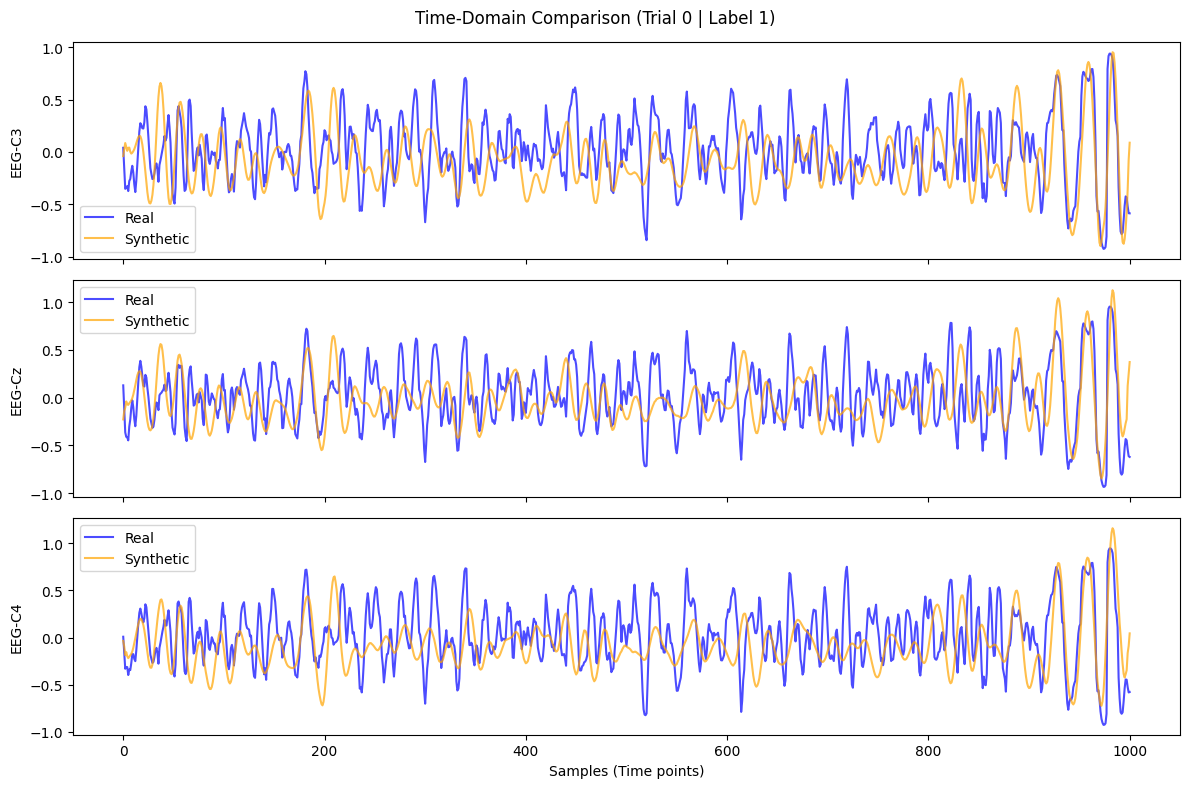

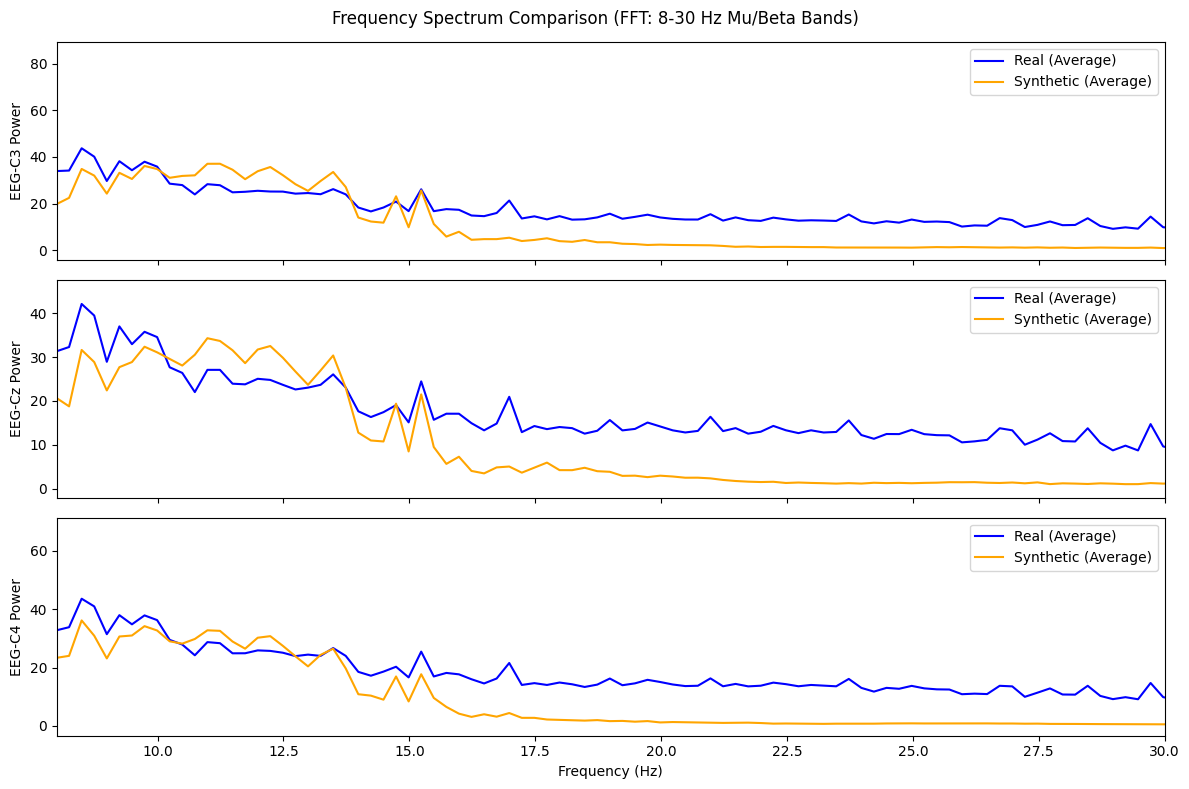

Calculating similarity metrics...
Pearson Correlation per channel (C3, Cz, C4): [np.float64(0.8393), np.float64(0.8228), np.float64(0.8027)]
Sliced Wasserstein Distance (SWD): 0.1726


In [8]:
# STEP 1: GENERATE SYNTHETIC DATA FOR SUBJECT 1 DEMO
print("Training Demo Subject 1 Generator...")
demo_generator = train_wgan_gp_for_subject(X_train_norm_demo, y_train_demo, epochs=100, verbose=True)

noise = np.random.normal(size=(len(y_train_demo), latent_dim)).astype(np.float32)
y_fake = y_train_demo.copy()
synthetic_raw = demo_generator.predict([noise, y_fake[:, np.newaxis]], verbose=0)

# Transpose back to (samples, channels, time) format
X_fake = np.transpose(synthetic_raw, (0, 2, 1))
print("Generated synthetic EEG shape:", X_fake.shape)

# STEP 2: TIME DOMAIN PLOTS
import scipy.stats

trial_idx = 0
channels = ["EEG-C3", "EEG-Cz", "EEG-C4"]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ch_idx, ch_name in enumerate(channels):
    axes[ch_idx].plot(X_train_norm_demo[trial_idx, ch_idx, :], label="Real", color="blue", alpha=0.7)
    axes[ch_idx].plot(X_fake[trial_idx, ch_idx, :], label="Synthetic", color="orange", alpha=0.7)
    axes[ch_idx].set_ylabel(ch_name)
    axes[ch_idx].legend()

axes[2].set_xlabel("Samples (Time points)")
plt.suptitle(f"Time-Domain Comparison (Trial {trial_idx} | Label {y_train_demo[trial_idx]})")
plt.tight_layout()
plt.show()

# STEP 3: FREQUENCY SPECTRA PLOTS (FFT)
sfreq = 250
freqs = np.fft.rfftfreq(1001, d=1/sfreq)

real_fft = np.abs(np.fft.rfft(X_train_norm_demo, axis=2))
fake_fft = np.abs(np.fft.rfft(X_fake, axis=2))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ch_idx, ch_name in enumerate(channels):
    axes[ch_idx].plot(freqs, real_fft.mean(axis=0)[ch_idx, :], label="Real (Average)", color="blue")
    axes[ch_idx].plot(freqs, fake_fft.mean(axis=0)[ch_idx, :], label="Synthetic (Average)", color="orange")
    axes[ch_idx].set_xlim(8, 30) # Focus on Mu and Beta bands
    axes[ch_idx].set_ylabel(f"{ch_name} Power")
    axes[ch_idx].legend()

axes[2].set_xlabel("Frequency (Hz)")
plt.suptitle("Frequency Spectrum Comparison (FFT: 8-30 Hz Mu/Beta Bands)")
plt.tight_layout()
plt.show()

# STEP 4: QUANTITATIVE METRICS
print("Calculating similarity metrics...")

# Pearson Correlation
pearson_coeffs = []
for ch in range(3):
    avg_real = np.mean(X_train_norm_demo[:, ch, :], axis=0)
    avg_fake = np.mean(X_fake[:, ch, :], axis=0)
    r, _ = scipy.stats.pearsonr(avg_real, avg_fake)
    pearson_coeffs.append(r)

print(f"Pearson Correlation per channel (C3, Cz, C4): {[round(x, 4) for x in pearson_coeffs]}")

# Sliced Wasserstein Distance (SWD)
def sliced_wasserstein_distance(X_real_data, X_fake_data, n_projections=50):
    N_real = X_real_data.shape[0]
    N_fake = X_fake_data.shape[0]
    real_flat = X_real_data.reshape(N_real, -1)
    fake_flat = X_fake_data.reshape(N_fake, -1)
    dim = real_flat.shape[1]
    
    swd_sum = 0.0
    for _ in range(n_projections):
        proj = np.random.normal(size=(dim,))
        proj /= np.linalg.norm(proj)
        p_real = np.dot(real_flat, proj)
        p_fake = np.dot(fake_flat, proj)
        swd_sum += scipy.stats.wasserstein_distance(p_real, p_fake)
    return swd_sum / n_projections

swd_score = sliced_wasserstein_distance(X_train_norm_demo, X_fake)
print(f"Sliced Wasserstein Distance (SWD): {swd_score:.4f}")


### PHASE 5: DATA AUGMENTATION & FINAL TESTING

Evaluating the impact of synthetic EEG data augmentation by training subject-specific CSP + SVM classifiers on individual augmented subject datasets (Real + Synthetic) and evaluating them on the unseen test set of each subject.


In [9]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from mne.decoding import CSP
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [11]:
# STEP 1: DEFINE SUBJECT-WISE PIPELINE LOOP
def train_and_evaluate_subject(subject_id, epochs_wgan=100):
    # 1. Load single-subject data
    X_train_raw, y_train_subj = load_and_preprocess_subject(subject_id, "T")
    X_test_raw, y_test_subj = load_and_preprocess_subject(subject_id, "E")
    
    # 2. Z-score normalize individually (across-channels to preserve relative variance)
    X_train_subj, X_test_subj = z_score_normalize_subject(X_train_raw, X_test_raw)
    
    # 3. Train Subject-Specific WGAN-GP
    print(f"-> Training WGAN-GP on Subject A{subject_id:02d} for {epochs_wgan} epochs...")
    generator_subj = train_wgan_gp_for_subject(X_train_subj, y_train_subj, epochs=epochs_wgan, verbose=False)
    
    # 4. Prepare data augmentation
    noise_train = np.random.normal(size=(len(X_train_subj), latent_dim)).astype(np.float32)
    y_fake_train = y_train_subj.copy()
    synthetic_raw_train = generator_subj.predict([noise_train, y_fake_train[:, np.newaxis]], verbose=0)
    X_fake_train = np.transpose(synthetic_raw_train, (0, 2, 1))

    # Augmented training set (Real Train + Synthetic Train)
    X_aug = np.concatenate([X_train_subj, X_fake_train], axis=0)
    y_aug = np.concatenate([y_train_subj, y_fake_train], axis=0)

    # Shuffle the augmented training portion
    shuffle_idx = np.random.permutation(len(X_aug))
    X_aug = X_aug[shuffle_idx]
    y_aug = y_aug[shuffle_idx]
    
    # 5. Train CSP + SVM Classifier on the augmented dataset
    # Updated n_components to 4 and reg to 'ledoit_wolf' for 22 channels robustness
    csp = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)
    svm_model = Pipeline([
        ('csp', csp),
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=10.0, class_weight='balanced', random_state=42))
    ])
    svm_model.fit(X_aug, y_aug)
    
    # 6. Evaluate on Unseen Test Set
    preds_aug = svm_model.predict(X_test_subj)
    acc = accuracy_score(y_test_subj, preds_aug)
    prec = precision_score(y_test_subj, preds_aug, average="macro", zero_division=0)
    rec = recall_score(y_test_subj, preds_aug, average="macro", zero_division=0)
    f1 = f1_score(y_test_subj, preds_aug, average="macro", zero_division=0)
    
    return acc, prec, rec, f1

# STEP 2: RUN THE SUBJECT-WISE PIPELINE FOR ALL 9 SUBJECTS
print("\n" + "="*79)
print("STARTING INDIVIDUAL SUBJECT WGAN-GP AUGMENTED CSP+SVM EVALUATION")
print("="*79)

subject_results = {}
epochs_wgan_value = 100

for subject in range(1, 10):
    print(f"\n[SUBJECT A{subject:02d}]")
    acc, prec, rec, f1 = train_and_evaluate_subject(subject, epochs_wgan=epochs_wgan_value)
    subject_results[subject] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
    print(f"Subject A{subject:02d} Results - Accuracy: {acc:.4f}, F1: {f1:.4f}")

# STEP 3: PRINT SUMMARY METRICS ACROSS ALL 9 SUBJECTS
print("\n" + "="*79)
print("INDIVIDUAL SUBJECT-WISE EVALUATION SUMMARY (AUGMENTED)")
print("="*79)

accs = [res["accuracy"] for res in subject_results.values()]
precs = [res["precision"] for res in subject_results.values()]
recs = [res["recall"] for res in subject_results.values()]
f1s = [res["f1"] for res in subject_results.values()]

for subject, res in subject_results.items():
    print(f"Subject A{subject:02d} | Accuracy: {res['accuracy']:.4f} | F1 Score: {res['f1']:.4f}")
    
print("-" * 50)
print(f"Average Accuracy : {np.mean(accs):.4f} +/- {np.std(accs):.4f}")
print(f"Average Precision: {np.mean(precs):.4f} +/- {np.std(precs):.4f}")
print(f"Average Recall   : {np.mean(recs):.4f} +/- {np.std(recs):.4f}")
print(f"Average F1 Score : {np.mean(f1s):.4f} +/- {np.std(f1s):.4f}")
print("="*79 + "\n")



STARTING INDIVIDUAL SUBJECT WGAN-GP AUGMENTED CSP+SVM EVALUATION

[SUBJECT A01]
-> Training WGAN-GP on Subject A01 for 100 epochs...
Computing rank from data with rank=None
    Using tolerance 10 (2.2e-16 eps * 22 dim * 2e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Subject A01 Results - Accuracy: 0.6250, F1: 0.6055

[SUBJECT A02]
-> Training WGAN-GP on Subject A02 for 100 epochs...
Computing rank from data with rank=None
    Using tolerance 11 (2.2e-16 eps * 22 dim * 2.2e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Subject A02 Results - Accuracy: 0.5625, F

## Subject-wise real only svm

In [ ]:
# STEP 1: SUBJECT-WISE REAL-ONLY PIPELINE LOOP (NO DATA AUGMENTATION)
def evaluate_real_only_subject(subject_id):
    # 1. Load single-subject data
    X_train_raw, y_train_subj = load_and_preprocess_subject(subject_id, "T")
    X_test_raw, y_test_subj = load_and_preprocess_subject(subject_id, "E")
    
    # 2. Z-score normalize individually (across-channels to preserve relative variance)
    X_train_subj, X_test_subj = z_score_normalize_subject(X_train_raw, X_test_raw)
    
    # 3. Train CSP + SVM Classifier on the real dataset only
    # Updated n_components to 4 and reg to 'ledoit_wolf' for 22 channels robustness
    csp = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)
    svm_model = Pipeline([
        ('csp', csp),
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=10.0, class_weight='balanced', random_state=42))
    ])
    svm_model.fit(X_train_subj, y_train_subj)
    
    # 4. Evaluate on Unseen Test Set
    preds_real = svm_model.predict(X_test_subj)
    acc = accuracy_score(y_test_subj, preds_real)
    prec = precision_score(y_test_subj, preds_real, average="macro", zero_division=0)
    rec = recall_score(y_test_subj, preds_real, average="macro", zero_division=0)
    f1 = f1_score(y_test_subj, preds_real, average="macro", zero_division=0)
    
    return acc, prec, rec, f1

# STEP 2: RUN THE REAL-ONLY PIPELINE FOR ALL 9 SUBJECTS
print("\n" + "="*79)
print("STARTING INDIVIDUAL SUBJECT REAL-ONLY CSP+SVM EVALUATION")
print("="*79)

real_results = {}
for subject in range(1, 10):
    acc, prec, rec, f1 = evaluate_real_only_subject(subject)
    real_results[subject] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
    print(f"Subject A{subject:02d} Baseline - Accuracy: {acc:.4f}, F1: {f1:.4f}")

# STEP 3: PRINT SUMMARY METRICS ACROSS ALL 9 SUBJECTS
print("\n" + "="*79)
print("INDIVIDUAL SUBJECT-WISE EVALUATION SUMMARY (REAL-ONLY)")
print("="*79)

real_accs = [res["accuracy"] for res in real_results.values()]
real_precs = [res["precision"] for res in real_results.values()]
real_recs = [res["recall"] for res in real_results.values()]
real_f1s = [res["f1"] for res in real_results.values()]

for subject, res in real_results.items():
    print(f"Subject A{subject:02d} | Accuracy: {res['accuracy']:.4f} | F1 Score: {res['f1']:.4f}")
    
print("-" * 50)
print(f"Average Accuracy : {np.mean(real_accs):.4f} +/- {np.std(real_accs):.4f}")
print(f"Average Precision: {np.mean(real_precs):.4f} +/- {np.std(real_precs):.4f}")
print(f"Average Recall   : {np.mean(real_recs):.4f} +/- {np.std(real_recs):.4f}")
print(f"Average F1 Score : {np.mean(real_f1s):.4f} +/- {np.std(real_f1s):.4f}")
print("="*79 + "\n")



STARTING INDIVIDUAL SUBJECT REAL-ONLY CSP+SVM EVALUATION (BASELINE)
Computing rank from data with rank=None
    Using tolerance 0.42 (2.2e-16 eps * 3 dim * 6.3e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Subject A01 Baseline - Accuracy: 0.4375, F1: 0.4342
Computing rank from data with rank=None
    Using tolerance 0.43 (2.2e-16 eps * 3 dim * 6.4e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Subject A02 Baseline - Accuracy: 0.5694, F1: 0.5334
Computing rank from data with rank=None
    Using tolerance 0.42 (2.2e-16 eps * 3 dim * 6.3e+14  max singular value)
    Estimated rank

In [ ]:
# STEP 1: PREPARE REAL-ONLY DATA (Squeeze the singleton dimension for CSP)
X_train_real_3d = np.squeeze(X_train, axis=-1)
X_test_real_3d = np.squeeze(X_test, axis=-1)

# STEP 2: DEFINE AND TRAIN CSP + SVM CLASSIFIER ON REAL DATA ONLY
print("Training CSP + SVM Classifier on Real Data Only (No GAN Augmentation)...")
svm_real_model = Pipeline([
    ('csp', CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)),
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10.0, class_weight='balanced', random_state=42))
])

svm_real_model.fit(X_train_real_3d, y_train)

# STEP 3: EVALUATE ON THE UNSEEN REAL TEST SET
preds_real = svm_real_model.predict(X_test_real_3d)
acc_real = accuracy_score(y_test, preds_real)
prec_real = precision_score(y_test, preds_real, average="macro", zero_division=0)
rec_real = recall_score(y_test, preds_real, average="macro", zero_division=0)
f1_real = f1_score(y_test, preds_real, average="macro", zero_division=0)

print("\n" + "="*79)
print("REAL-ONLY SVM MODEL RESULTS ON UNSEEN TEST SET")
print("="*79)
print(f"Accuracy :", acc_real)
print(f"Precision:", prec_real)
print(f"Recall   :", rec_real)
print(f"F1 Score :", f1_real)
print("\nClassification report:\n")
print(classification_report(y_test, preds_real, digits=4, zero_division=0))
print("="*79 + "\n")


Training CSP + SVM Classifier on Real Data Only (No GAN Augmentation)...
Computing rank from data with rank=None


    Using tolerance 1.3 (2.2e-16 eps * 3 dim * 1.9e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.

REAL-ONLY SVM MODEL RESULTS ON UNSEEN TEST SET
Accuracy : 0.5011583011583012
Precision: 0.501157413609255
Recall   : 0.5010303967027305
F1 Score : 0.487018641157714

Classification report:

              precision    recall  f1-score   support

           0     0.5012    0.3354    0.4019       647
           1     0.5012    0.6667    0.5722       648

    accuracy                         0.5012      1295
   macro avg     0.5012    0.5010    0.4870      1295
weighted avg     0.5012    0.5012    0.4871      1295


